# Interpretation & Visualization
## Descriptive Statistics and Communicating Findings with matplotlib

> **Disclaimer:** This notebook was generated with the assistance of AI and has been human-reviewed for accuracy and quality.

**Topics Covered:**
- Descriptive Statistics (mean, median, variance)
- The challenge of communicating data findings
- Introduction to matplotlib
- Choosing the right visualization

## 1. Descriptive Statistics — Making Sense of Your Data

Before you can visualize anything, you need to *understand* your data.  
**Descriptive statistics** are summary numbers that describe the key features of a dataset.

In a business setting, descriptive statistics let us answer questions like:
- "How long does a typical customer wait in line?"
- "Were this month’s sales consistent, or did they swing wildly day to day?"
- "Is there a big gap between what most customers experience and what a few unlucky ones experience?"

The three statistics we will focus on are:

| Statistic | What it tells you | Python function |
|-----------|------------------|-----------------|
| **Mean** | The arithmetic average — the "center of gravity" of your data | `statistics.mean()` |
| **Median** | The middle value when sorted — resistant to extreme outliers | `statistics.median()` |
| **Variance** | How spread out the values are — high variance means unpredictable | `statistics.variance()` |

> **Why sample statistics?**  
> We rarely have data on every single event (the *population*).  
> Instead, we work with a *sample* — the data we actually collected — and use it to estimate the true picture.  
> For example, instead of tracking every customer all year, we might measure wait times
> for 14 days and draw conclusions from that sample.

---
### 1a. The Difficulty of Real Data

Now suppose our business runs **two service lanes** and leadership asks:  
*"Which lane is performing better? Just give me the average."*

This is where things get tricky. We will collect wait times for 30 customers per lane,
compute the statistics.

Pay attention to what the sample parameters **hide**.

In [3]:
# These two lines load the tools we need to make charts and compute statistics.
# You will learn what they mean soon — for now, just make sure to run this cell first.
import matplotlib.pyplot as plt
import statistics

# -----------------------------------------------------------------
# Data: wait times (in minutes) for 30 customers in each service lane
# We want wait times to be LOW
# -----------------------------------------------------------------
express_lane = [
    8, 9, 7, 8, 10, 8, 9, 7, 8, 9,
    8, 7, 9, 8, 10, 8, 9, 7, 8, 9,
    8, 7, 9, 8, 10, 9, 8, 7, 9, 8
]

standard_lane = [
    1, 2, 1, 3, 1, 2, 1, 1, 2, 3,
    1, 2, 1, 3, 2, 1, 2, 1, 1, 2,
    3, 1, 2, 1, 2, 45, 38, 42, 35, 50
]

mean_express  = statistics.mean(express_lane)
mean_standard = statistics.mean(standard_lane)

print("Express Lane  — Mean wait:", mean_express)
print("Standard Lane — Mean wait", mean_standard)


Express Lane  — Mean wait: 8.3
Standard Lane — Mean wait 8.4


The means look almost identical. Does that mean both lanes are equally good? Let's look at a few different visualizations and see if they agree.

### Visualization 1 — Line Plot

`plt.plot()` connects each value in the list with a line, in the order the values appear.
We draw both lanes on the same chart so we can compare them side by side.

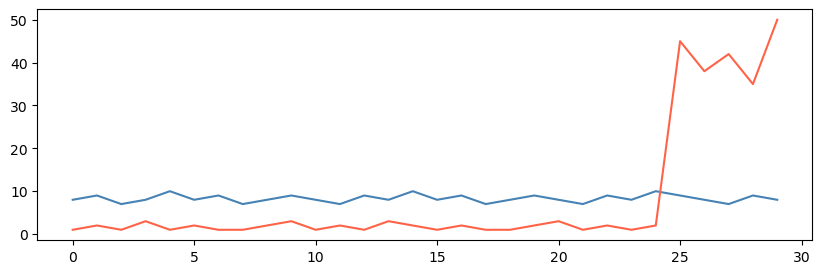

In [4]:
plt.figure(figsize=(10, 3))
plt.plot(express_lane,  color="steelblue")
plt.plot(standard_lane, color="tomato")
plt.show()

The red line spikes sharply near the end — that is where the outliers happen to sit in the list.
But the position of a customer in the list is arbitrary; it is not a timeline.

A line chart implies the x-axis represents something ordered, like time passing.
Here it does not, so the spike is an accident of how we wrote the list, not a real pattern.

**What it hides:** almost everything. The shape of the line changes completely
if you shuffle the data.

### Visualization 2 — Bar Chart

`plt.bar()` draws one bar per group.
Here we pass in the two means we already calculated so each bar represents the average wait time.

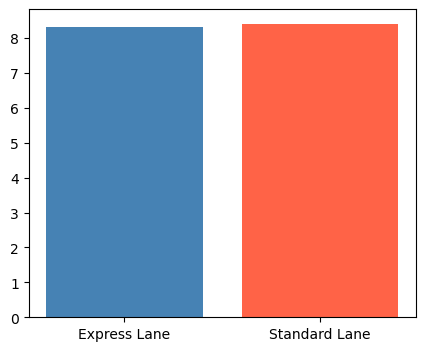

In [5]:
plt.figure(figsize=(5, 4))
plt.bar(
    ["Express Lane", "Standard Lane"],
    [mean_express, mean_standard],
    color=["steelblue", "tomato"]
)
plt.show()

Both bars are nearly the same height — 8.3 min vs 8.4 min.
A manager glancing at this chart would likely say: *"Both lanes are performing equally. No action needed."*

But five customers in the Standard Lane waited between 35 and 50 minutes.
The bar chart collapses all 30 data points into a single number and throws the rest away.

**What it hides:** the spread of the data, and any extreme values.

### Visualization 3 — Histogram

`plt.hist()` splits the range of values into equal-width buckets (called **bins**)
and draws a bar showing how many data points fell into each bucket.
The `alpha` argument controls transparency so both lanes can be seen at once.

In [1]:
import numpy as np

plt.figure(figsize=(10, 4))
plt.hist(express_lane,  bins=20, range=(0, 50), color="steelblue", alpha=0.6)
plt.hist(standard_lane, bins=20, range=(0, 50), color="tomato",    alpha=0.6)
plt.show()

NameError: name 'plt' is not defined

Now we can see two very different shapes.

- **Blue (Express Lane):** a tight cluster packed between 7 and 10 minutes. Very consistent.
- **Red (Standard Lane):** a tall cluster near 1–3 minutes, then a gap, then a few bars out near 35–50 minutes.

This is much more informative than the bar chart.
But the histogram still does not show us individual customers or exact values —
we only see counts per bucket.

**What it hides:** individual data points and exact wait times.

### Visualization 4 — Scatter Plot

`plt.scatter()` draws one dot per data point, so nothing is aggregated or hidden.
We place all Express Lane dots at x=0 and all Standard Lane dots at x=1
so the two groups appear as vertical columns we can compare directly.
The `s` argument controls dot size.

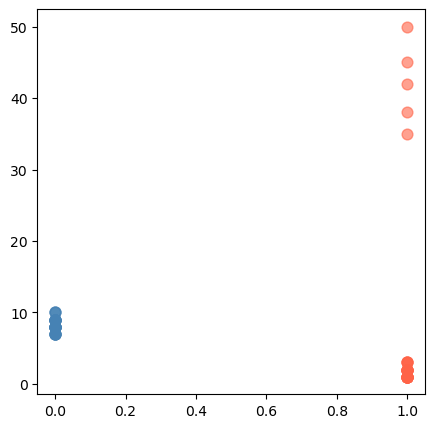

In [14]:
plt.figure(figsize=(5, 5))
plt.scatter([0] * len(express_lane),  express_lane,  color="steelblue", alpha=0.6, s=60)
plt.scatter([1] * len(standard_lane), standard_lane, color="tomato",    alpha=0.6, s=60)
plt.show()

---
**Key takeaway**

| Visualization | What it revealed | What it hid |
|--------------|-----------------|-------------|
| Line plot | Nothing useful — actively misleading | Order is arbitrary |
| Bar chart | Averages look equal | All spread and outliers |
| Histogram | Two very different distributions | Exact values, individual points |
| Scatter plot | Every individual customer | Nothing significant |

No single visualization tells the whole story.
A good data analyst looks at several before drawing any conclusions.

---
## 2. Importing Modules

Python comes with a large collection of pre-written code organized into files called **modules**.
A module is just a file full of functions, constants, and tools that someone else already wrote.
Instead of writing everything from scratch, you can load one of these files and use what is inside it.

The word `import` is how you tell Python to load a module.
Once a module is imported, you access its contents using a dot:

```
module_name.function_name()
```

The modules we will use in this section come from Python’s **standard library** —
a set of modules that ship with Python and are always available, no extra installation needed.

### 2a. Importing from the Standard Library

Two modules from the standard library will appear throughout this course:

| Module | What it contains |
|--------|------------------|
| `math` | Mathematical constants (`pi`) and functions (`sqrt`, `floor`, `ceil`) |
| `statistics` | Tools for summarizing data (`mean`, `median`, `variance`) |

After importing, every function or constant inside the module is accessed with a dot.

In [9]:
import math
import statistics

# --- math module ---
print(math.pi)           # the constant pi (3.14159...)
print(math.sqrt(25))     # square root of 25  -> 5.0 (literally passing in an argument of 25 in the parametre for the sqrt() fuction)
print(math.floor(3.9))   # round DOWN to nearest whole number -> 3
print(math.ceil(3.1))    # round UP to nearest whole number   -> 4

# --- This will error out! ---
#print(sqrt(25))

# this is more human friendly even though it does the same thing as the print(round(statistics.mean(scores)),2)

value = statistics.means(scores)
rounded = round (value, 2)
print()

# --- statistics module ---
scores = [72, 85, 90, 61, 78, 95, 83]
print(round(statistics.mean(scores)),2)      # average (U WILL BE USING THESE FUNCTIONS FOR TLAB pART 2) and we call the module first like statistics.mean OR use use an alias!
print(statistics.median(scores))    # middle value
print(statistics.variance(scores))  # spread

# this is more human friendly even though it does the same thing as the print(round(statistics.mean(scores)),2)

value = statistics.means(scores)
rounded = round (value, 2)

3.141592653589793
5.0
3
4

81 2
83
130.95238095238096


Notice the pattern: `module_name.function_name(argument)`.
The dot is how Python knows to look *inside* the module for that function.

If you try to call `sqrt(25)` without `math.` in front, Python will raise a `NameError`
because `sqrt` on its own is not defined — it only exists inside `math`.

### 2b. Renaming a Module on Import

You can give a module a shorter nickname using `as`.
This is useful when a module name is long and you will be typing it many times.

```python
import module_name as nickname
```

After this, you use the nickname everywhere instead of the full name.
The most common nicknames you will see in data work are `plt` for `matplotlib.pyplot`
and `stats` for `statistics`.

In [24]:
import math as m
import statistics as stats

scores = [72, 85, 90, 61, 78, 95, 83]

# Same functions as before, but now we use the short alias
print(m.sqrt(25))           # math.sqrt using the alias 'm'
print(m.floor(3.9))         # math.floor using the alias 'm'

print(stats.mean(scores))   # statistics.mean using the alias 'stats'
print(stats.median(scores)) # statistics.median using the alias 'stats'

5.0
3
80.57142857142857
83


The alias only exists inside the file (or notebook cell) where you wrote the `import` statement.
After `import math as m`, the name `math` no longer works — only `m` does.

You will see `import matplotlib.pyplot as plt` throughout this course.
That is exactly this pattern: `matplotlib.pyplot` is the full module name, and `plt` is the alias.

### 2c. Importing Specific Items with `from`

Sometimes you only need one or two things from a module.
The `from` keyword lets you import just those items directly into your code,
so you do not need to type the module name at all when you use them.

```python
from module_name import item_one, item_two
```

In [25]:
from math import sqrt, pi, floor
from statistics import mean, median

# No module prefix needed
print(sqrt(49))    # no 'math.' in front
print(pi)          # the constant, used directly
print(floor(4.9))  # no 'math.' in front

print()

scores = [72, 85, 90, 61, 78, 95, 83]
print(mean(scores))    # no 'statistics.' in front
print(median(scores))  # no 'statistics.' in front

7.0
3.141592653589793
4

80.57142857142857
83


**When to use which style:**

| Style | Example | Best when |
|-------|---------|----------|
| `import module` | `import math` | You need many things from the module |
| `import module as alias` | `import matplotlib.pyplot as plt` | The module name is long and you use it constantly |
| `from module import item` | `from math import sqrt` | You only need one or two specific things |

There is no wrong answer — all three styles produce the same result.
Consistency within a project matters more than which style you pick.

---
## Exercise 2 — Import and Use a New Module

Python’s `random` module generates random numbers. You have not seen it before,
but the import rules are exactly the same as `math` and `statistics`.

The one function you need is `random.randint(a, b)`,
which returns one random whole number between `a` and `b` (both ends included).

**Steps:**
1. Import the `random` module
2. Build a list called `rolls` that holds 6 calls to `random.randint(1, 6)`
   (simulating six rolls of a six-sided die)
3. Import `mean` and `median` from the `statistics` module using the `from` style
4. Print `rolls`, the mean of `rolls`, and the median of `rolls`

**Expected output** (your numbers will differ since they are random):
```
Rolls  : [3, 6, 1, 4, 4, 2]
Mean   : 3.3333333333333335
Median : 3.5
```

> Hint: build the list the same way you built lists before —
> `[random.randint(1, 6), random.randint(1, 6), ...]`

In [ ]:
# Step 1: import the random module
import random as r

# Step 2: build a list of 6 random die rolls (each between 1 and 6) OR we do a for loop with the range 
# rolls = [r.randint(1,6),r.randint(1,6),r.randint(1,6),r.randint(1,6),r.randint(1,6),r.randint(1,6)]
rolls = []
for i in range(0,6):
    rolls.append(r.randint(1,6))

# Step 3: import mean and median from the statistics module
from statistics import mean, median 

# Step 4: print rolls, the mean, and the median
print("Rolls  :", rolls)
print("Mean   :", round(mean(rolls),2))
print("Median :", median(rolls)) 

Rolls  : [1, 5, 5, 6, 3, 2]
Mean   : 3.67
Median : 4.0


---
## 3. Introduction to matplotlib

**matplotlib** is the most widely used data visualization library in Python.
It is not part of the standard library, but it comes pre-installed in most data science environments.
You bring it in with:

```python
import matplotlib.pyplot as plt
```

The part we use is called `pyplot` (a sub-module inside matplotlib).
We rename it `plt` because we will type it constantly.

### The explicit approach

There are two ways to build charts in matplotlib.
In this section we use the **explicit** approach, which is the recommended style.
You start by creating two objects and then call drawing functions on them:

```python
fig, ax = plt.subplots()
```

| Object | What it is |
|--------|------------|
| `fig` | The whole figure — think of it as the canvas or the page |
| `ax`  | The axes — the actual area where data is drawn |

Once you have `ax`, you call drawing methods on it: `ax.plot()`, `ax.bar()`, `ax.hist()`.
Finish with `plt.show()` to display the chart.

```
fig, ax = plt.subplots()   <- create the canvas and axes
ax.plot(...)               <- draw on the axes
plt.show()                 <- display it
```

### 3a. Line Plot — One List

`ax.plot()` draws a line that connects your data points in order.
When you pass **one list**, matplotlib automatically uses the position in the list (0, 1, 2, ...)
as the x-axis and the values in your list as the y-axis.

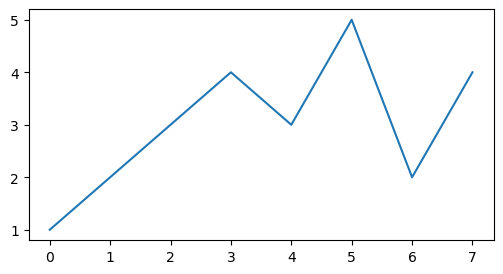

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots
ax.plot([1, 2, 3, 4, 3, 5, 2, 4])
plt.show()

The x-axis shows positions 0 through 7 — the index of each value in the list.
The y-axis shows the values themselves.

matplotlib connects the dots in the exact order they appear in the list,
so the shape of the line reflects how the values rise and fall as you move through it.

### 3b. Line Plot — Two Lists

When you pass **two lists**, the first becomes the x-axis and the second becomes the y-axis.
This lets you control exactly what label or value appears at each point.

```python
ax.plot(x_values, y_values)
```

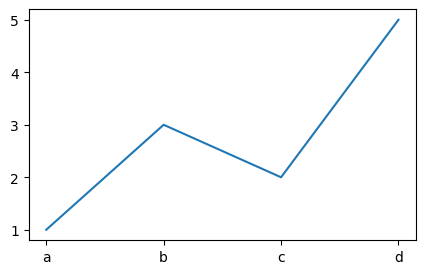

In [28]:
x = ["a", "b", "c", "d"]
y = [1, 3, 2, 5]

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y)
plt.show()

Now the x-axis shows the labels `a`, `b`, `c`, `d` instead of index numbers.
In a real scenario these could be months, product names, department names, or anything categorical.

Notice that `x` and `y` must have the same length —
each label in `x` is paired with exactly one value in `y`.

### 3c. Bar Chart — Same Data, Different Chart Type

A bar chart uses the exact same two-list structure as `ax.plot()`.
The only change is the method name: `ax.bar()` instead of `ax.plot()`.

This is a key insight: **the data does not change, only how we choose to display it.**

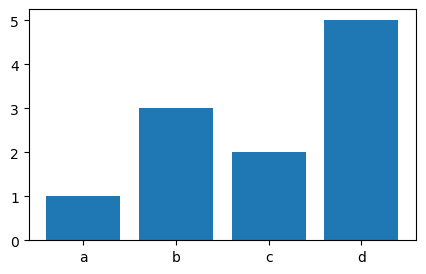

In [29]:
x = ["a", "b", "c", "d"]
y = [1, 3, 2, 5]

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(x, y)
plt.show()

The same four data points from 3b, now shown as bars instead of a connected line.

Bar charts are better than line charts for **categorical** data (like names or labels)
because a bar chart does not imply any connection or trend between the categories.
A line between `"a"` and `"b"` suggests they are part of a sequence — often that is misleading.

### 3d. Histogram — Controlling the Number of Bins

A histogram takes **one list** of numbers and groups them into buckets called **bins**.
Each bar shows how many values fell into that bucket.

The `bins` argument controls how many buckets the data is split into.
Fewer bins gives a broader view; more bins reveals finer detail.

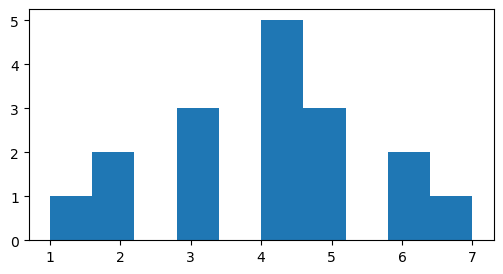

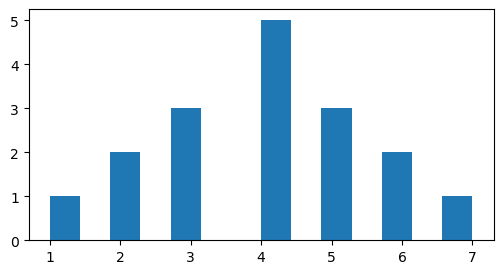

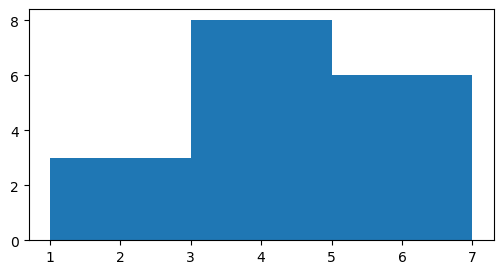

In [30]:
data = [1, 2, 2, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 6, 6, 7]

# Default number of bins (matplotlib chooses automatically)
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(data)
plt.show()

# More bins -- each bar covers a smaller range, so we see finer detail
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(data, bins=14)
plt.show()

# Fewer bins -- data is grouped into broader buckets, the overall shape is clearer
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(data, bins=3)
plt.show()

All three histograms show the same 17 values.

- **Default bins:** a reasonable starting point — you can see the peak around 4 and 5.
- **14 bins:** each value gets its own bar, so you can see exactly how many times
  each number appears.
- **3 bins:** the data collapses into three wide buckets.
  The detail is gone but the overall shape (low → peak → taper) is still visible.

There is no single correct number of bins.
In practice you try a few values and pick the one that best communicates the pattern in your data.

---
## Exercise 3 — Heart Rate Analysis

The file `example_data.txt` contains 63 heart rate readings (in beats per minute)
recorded from a single participant over a period of time.

Your job is to load the data, visualize it, and use descriptive statistics to figure out
what the participant was most likely doing when the readings were taken.

**Steps:**
1. Open `example_data.txt` and read all lines
2. Loop over the lines, strip each one, convert to `int`, and append to a list called `heart_rate`
3. Create a line chart of `heart_rate` using the explicit method
4. Compute the mean, median, and variance of `heart_rate` using the `statistics` module
5. Print the statistics and write your interpretation as a comment at the bottom

**Heart rate reference ranges:**

| Activity | Typical BPM |
|----------|-------------|
| Sleeping | 40 – 60 |
| Going about the day (resting, light tasks) | 60 – 100 |
| Exercising (moderate to intense) | 100 – 170+ |

> Hint: the steps for reading a file and converting strings to ints follow
> the same pattern from Section 4 of `control_flow.ipynb`:
> open the file, loop over lines, strip, cast, append.

In [ ]:
# import the matplotlib and statistics modules

# Step 1: open the file and read all lines into a list
obj = open("example_data.txt")
lines = ...

# Step 2: build the heart_rate list
# Loop over lines, strip whitespace, convert each value to int, and append
heart_rate = []
for line in lines:
    ...

In [ ]:
print("Number of readings :", len(heart_rate))
print("First five readings:", heart_rate[:5])
print()

In [ ]:
# Step 3: create a line chart of heart_rate using the explicit method
fig, ax = plt.subplots(...)
ax.plot(...)
plt.show()

In [ ]:
# Step 4: compute descriptive statistics
mean_hr     = ...
median_hr   = ...
variance_hr = ...

print("Mean    :", mean_hr)
print("Median  :", median_hr)
print("Variance:", variance_hr)
print()


In [ ]:

# Step 5: interpret the data
# Look at the line chart and the statistics above.
# Use the reference ranges in the exercise prompt to make your best guess.
#
# Was the participant sleeping, going about their day, or exercising?
# What in the data supports your conclusion?
#
# Your interpretation:
# ...